In [1]:
# Cell 0 — Mount Google Drive and extract dataset
# ── Step 1: Run on your LOCAL machine ──
# cd /Users/BAEK/Code/gaitkeeper
# zip -r data_processed.zip data_processed/
#
# ── Step 2: Upload data_processed.zip to MyDrive/Colab/ in Google Drive ──
# ── Step 3: Run cells top to bottom ──

from google.colab import drive
import zipfile, os

drive.mount('/content/drive')

ZIP_PATH = '/content/drive/MyDrive/Colab/data_processed.zip'

if not os.path.exists('/content/data_processed'):
    print('Extracting dataset...')
    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        zf.extractall('/content/')
    print('Done.')
else:
    print('Dataset already extracted.')

Mounted at /content/drive
Extracting dataset...
Done.


In [2]:
# Cell 1 — Installs
!pip install ultralytics kornia --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 34.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 75.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 126.7 MB/s eta 0:00:00


In [3]:
# Cell 2 — Imports
import cv2
import random
import numpy as np
import torch
import torch.nn.functional as F
import kornia
import kornia.augmentation as K
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
# Cell 3 — Config
# ── Training ──────────────────────────────────────────
PATCH_H       = 200    # patch height in pixels
PATCH_W       = 150    # patch width in pixels
PATCH_SCALE   = 0.5    # fraction of person bbox width (wider than V2's 0.3)
SHIRT_TOP     = 0.20   # top of shirt as fraction of person bbox height
SHIRT_BOT     = 0.60   # bottom of shirt as fraction of person bbox height
EPSILON       = 0.25   # max pixel delta from init (V2 was 0.15 — too tight)
LR            = 0.01
NUM_STEPS     = 500
EOT_N         = 6      # augmentations per step — all on the SAME sampled image
TOP_K         = 30     # fallback anchor count if no anchors in patch region
PERSON_LOSS_W = 0.5    # weight for direct person-class confidence loss
MASK_LOSS_W   = 0.5    # weight for mask suppression loss (was 0.4, worked well)

# ── Dataset ────────────────────────────────────────────
# True  → load pre-built training_samples.pkl from Drive (fast)
# False → re-extract frames from videos and save new pkl
USE_CACHED_SAMPLES = True

# ── Paths ──────────────────────────────────────────────
DRIVE_DIR        = '/content/drive/MyDrive/Colab'
IMAGE_PATH       = f'{DRIVE_DIR}/person.jpg'          # held-out eval image
VIDEO_DIR        = '/content/data_processed'
FRAMES_PER_VIDEO = 10
SAMPLES_PATH     = f'{DRIVE_DIR}/training_samples.pkl'

# ── Model ──────────────────────────────────────────────
YOLO_MODEL = 'yolov8n-seg'
DEVICE     = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')

Using device: cuda


In [5]:
# Cell 4 — Load YOLOv8-seg, freeze weights
yolo = YOLO(YOLO_MODEL)
torch_model = yolo.model.to(DEVICE)
torch_model.eval()

for p in torch_model.parameters():
    p.requires_grad_(False)

print(f'Model loaded: {YOLO_MODEL} | Parameters frozen: {sum(p.numel() for p in torch_model.parameters()):,}')

Model loaded: yolov8n-seg | Parameters frozen: 3,409,968


In [6]:
# Cell 5 — Forward pass helpers
def yolo_raw_forward(img_tensor):
    out = torch_model(img_tensor)
    return {'preds': out[0][0], 'proto': out[0][1]}

def img_to_tensor(img_np):
    """uint8 HxWx3 BGR numpy → [1, 3, 640, 640] float32 tensor on DEVICE"""
    img = cv2.resize(img_np, (640, 640))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    t = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
    return t.unsqueeze(0).to(DEVICE)

In [7]:
# Cell 6 — Shirt detection and patch placement
def detect_shirt_region(img_np):
    """
    Returns (shirt_box_img, shirt_box_mask) in 640x640 and 160x160 coords.
    Returns (None, None) if no person detected.
    """
    with torch.no_grad():
        results = yolo(cv2.resize(img_np, (640, 640)), verbose=False)

    if not results or results[0].boxes is None or len(results[0].boxes) == 0:
        return None, None

    boxes = results[0].boxes
    person_mask = (boxes.cls == 0)
    if not person_mask.any():
        return None, None

    best_idx = boxes.conf[person_mask].argmax()
    x1, y1, x2, y2 = boxes.xyxy[person_mask][best_idx].cpu().numpy()

    h, w = y2 - y1, x2 - x1
    cx = (x1 + x2) / 2
    half_w = w * PATCH_SCALE / 2
    sx1 = int(cx - half_w)
    sy1 = int(y1 + h * SHIRT_TOP)
    sx2 = int(cx + half_w)
    sy2 = int(y1 + h * SHIRT_BOT)

    scale = 160 / 640
    mx1 = max(0, int(sx1 * scale))
    my1 = max(0, int(sy1 * scale))
    mx2 = min(159, int(sx2 * scale))
    my2 = min(159, int(sy2 * scale))

    if mx2 <= mx1 or my2 <= my1:
        return None, None

    return (sx1, sy1, sx2, sy2), (mx1, my1, mx2, my2)


def paste_patch(img_tensor, patch, shirt_box):
    """Paste patch into img_tensor at shirt_box, preserving gradient through patch."""
    x1, y1, x2, y2 = [int(v) for v in shirt_box]
    w, h = x2 - x1, y2 - y1
    if w <= 0 or h <= 0:
        return img_tensor
    patch_resized = F.interpolate(patch, size=(h, w), mode='bilinear', align_corners=False)
    patched = img_tensor.clone()
    patched[:, :, y1:y2, x1:x2] = patch_resized
    return patched

In [8]:
# Cell 7 — Loss functions
#
# V3 fix: target preds[0, 4, :] directly — the PERSON class logit (class 0).
# V2 used max over all 80 classes, which often wasn't the person class.

def build_anchor_grid():
    """Pre-build YOLOv8 anchor center coords once. Reused every step."""
    strides, grids = [8, 16, 32], [80, 40, 20]
    cx_list, cy_list = [], []
    for stride, g in zip(strides, grids):
        xs = (torch.arange(g, device=DEVICE) + 0.5) * stride
        ys = (torch.arange(g, device=DEVICE) + 0.5) * stride
        yy, xx = torch.meshgrid(ys, xs, indexing='ij')
        cx_list.append(xx.reshape(-1))
        cy_list.append(yy.reshape(-1))
    return torch.cat(cx_list), torch.cat(cy_list)  # [8400], [8400]

ANCHOR_CX, ANCHOR_CY = build_anchor_grid()


def person_conf_loss(raw, patch_box_img):
    """
    Minimize person-class confidence (preds[0, 4, :] = class-0 logit)
    for anchors whose centers fall inside the patch region.
    V3 fix over V2: targets person class directly instead of max-over-80-classes.
    """
    preds = raw['preds']                        # [1, 116, 8400]
    person_logits = preds[0, 4, :]              # [8400] — class 0 = person
    person_conf   = torch.sigmoid(person_logits)

    px1, py1, px2, py2 = patch_box_img
    in_patch = (
        (ANCHOR_CX >= px1) & (ANCHOR_CX <= px2) &
        (ANCHOR_CY >= py1) & (ANCHOR_CY <= py2)
    )

    if in_patch.sum() > 0:
        return person_conf[in_patch].mean()

    # Fallback: nearest TOP_K anchors to patch center
    pcx = (px1 + px2) / 2
    pcy = (py1 + py2) / 2
    dist = (ANCHOR_CX - pcx).pow(2) + (ANCHOR_CY - pcy).pow(2)
    nearest = dist.topk(TOP_K, largest=False).indices
    return person_conf[nearest].mean()


def mask_suppression_loss(raw, patch_box_mask):
    """
    Assemble the segmentation mask for the best detection and minimize
    mask probability in the patch region. Degrades silhouette quality.
    """
    preds = raw['preds']   # [1, 116, 8400]
    proto = raw['proto']   # [1, 32, 160, 160]

    person_logits = preds[0, 4, :]              # person class only
    person_conf   = torch.sigmoid(person_logits)
    best = person_conf.argmax()

    if person_conf[best].item() < 0.05:
        return preds[0, 84:, 0].sum() * 0.0    # zero in-graph

    mask_coeff  = preds[0, 84:, best]           # [32]
    proto_flat  = proto[0].reshape(32, -1)      # [32, 160*160]
    mask_logits = (mask_coeff @ proto_flat).reshape(160, 160)
    mask_prob   = torch.sigmoid(mask_logits)

    x1, y1, x2, y2 = patch_box_mask
    patch_region = mask_prob[y1:y2, x1:x2]

    if patch_region.numel() == 0:
        return preds[0, 84:, 0].sum() * 0.0

    return patch_region.mean()


def combined_loss(raw, patch_box_img, patch_box_mask):
    p_loss = person_conf_loss(raw, patch_box_img)
    m_loss = mask_suppression_loss(raw, patch_box_mask)
    return PERSON_LOSS_W * p_loss + MASK_LOSS_W * m_loss

In [9]:
# Cell 8 — Differentiable EoT transforms via kornia
def apply_eot_transforms(patch):
    """patch: [1, 3, H, W] — returns augmented patch, gradient preserved."""
    p = patch

    if random.random() < 0.5:
        p = (p * random.uniform(0.6, 1.4)).clamp(0, 1)

    if random.random() < 0.5:
        p = K.ColorJitter(hue=0.1, saturation=0.1, p=1.0)(p)

    if random.random() < 0.5:
        angle = torch.tensor([random.uniform(-15, 15)], device=DEVICE)
        p = kornia.geometry.rotate(p, angle)

    if random.random() < 0.5:
        p = K.RandomPerspective(distortion_scale=0.2, p=1.0)(p)

    if random.random() < 0.5:
        ksize = random.choice([3, 5, 7])
        p = kornia.filters.motion_blur(p, kernel_size=ksize,
                                       angle=random.uniform(0, 360), direction=0.0)

    if random.random() < 0.5:
        p = p + torch.randn_like(p) * random.uniform(0, 10) / 255.0

    return p.clamp(0, 1)

In [10]:
# Cell 9 — Load or build training dataset
import pickle
from glob import glob

if USE_CACHED_SAMPLES:
    with open(SAMPLES_PATH, 'rb') as f:
        training_samples = pickle.load(f)
    print(f'Loaded {len(training_samples)} samples from {SAMPLES_PATH}')
else:
    def sample_frames_from_video(video_path, n_frames):
        cap = cv2.VideoCapture(video_path)
        total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        if total <= 0:
            cap.release()
            return []
        indices = [int(i * total / n_frames) for i in range(n_frames)]
        frames = []
        for idx in indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
            ret, frame = cap.read()
            if ret:
                frames.append(frame)
        cap.release()
        return frames

    video_paths = glob(f'{VIDEO_DIR}/**/*.mp4', recursive=True)
    print(f'Found {len(video_paths)} videos. Extracting frames...')

    training_samples = []
    for vp in sorted(video_paths):
        frames = sample_frames_from_video(vp, FRAMES_PER_VIDEO)
        valid = 0
        for frame in frames:
            b_img, b_mask = detect_shirt_region(frame)
            if b_img is not None:
                training_samples.append((frame, b_img, b_mask))
                valid += 1
        print(f'  {Path(vp).name}: {valid}/{len(frames)} frames detected')

    with open(SAMPLES_PATH, 'wb') as f:
        pickle.dump(training_samples, f)
    print(f'\nSaved {len(training_samples)} samples to {SAMPLES_PATH}')

print(f'Total training samples: {len(training_samples)}')

Loaded 280 samples from /content/drive/MyDrive/Colab/training_samples.pkl
Total training samples: 280


In [11]:
# Cell 10 — Initialize patch + baseline
img_eval = cv2.imread(IMAGE_PATH)
if img_eval is None:
    raise FileNotFoundError(f'Could not load {IMAGE_PATH}')

with torch.no_grad():
    raw_baseline = yolo_raw_forward(img_to_tensor(img_eval))
    box_eval_img, box_eval_mask = detect_shirt_region(img_eval)
    baseline_conf = person_conf_loss(raw_baseline, box_eval_img).item()

print(f'Baseline person conf in patch region: {baseline_conf:.4f}')

torch.manual_seed(42)
patch = torch.empty(1, 3, PATCH_H, PATCH_W, device=DEVICE).uniform_(0.4, 0.6)
patch.requires_grad_(True)
patch_init = patch.data.clone()

optimizer = torch.optim.Adam([patch], lr=LR)
print(f'Patch initialized: {list(patch.shape)}')

Baseline person conf in patch region: 0.5068
Patch initialized: [1, 3, 200, 150]


In [12]:
# Cell 11 — Training loop
#
# V3 fix: sample ONE image per step, apply all EOT augmentations to it.
# V2 sampled a different image per EOT iteration → conflicting gradients
# that cancelled each other, causing the loss to never converge.

if not training_samples:
    raise RuntimeError('No training samples — run Cell 9 first')

loss_history = []

for step in range(NUM_STEPS):
    optimizer.zero_grad()

    # Sample ONE image for this step
    img, box_img, box_mask = random.choice(training_samples)
    img_tensor = img_to_tensor(img)   # fixed for all EOT iters this step

    step_loss = 0.0
    for _ in range(EOT_N):
        aug_patch  = apply_eot_transforms(patch)
        patched    = paste_patch(img_tensor, aug_patch, box_img)
        raw        = yolo_raw_forward(patched)
        loss       = combined_loss(raw, box_img, box_mask) / EOT_N
        loss.backward()
        step_loss += loss.item()

    optimizer.step()

    with torch.no_grad():
        delta = (patch.data - patch_init).clamp(-EPSILON, EPSILON)
        patch.data = (patch_init + delta).clamp(0, 1)

    loss_history.append(step_loss)

    if step % 50 == 0:
        print(f'Step {step:3d}/{NUM_STEPS} | loss {step_loss:.4f}')

print('Training complete.')

Step   0/500 | loss 0.3988
Step  50/500 | loss 0.4953
Step 100/500 | loss 0.7294
Step 150/500 | loss 0.2837
Step 200/500 | loss 0.6445
Step 250/500 | loss 0.3338
Step 300/500 | loss 0.3614
Step 350/500 | loss 0.2851
Step 400/500 | loss 0.3163
Step 450/500 | loss 0.3048
Training complete.


In [13]:
# Cell 12 — Evaluation metrics
img_eval = cv2.imread(IMAGE_PATH)
img_tensor_eval = img_to_tensor(img_eval)
box_eval_img, box_eval_mask = detect_shirt_region(img_eval)

with torch.no_grad():
    raw_clean = yolo_raw_forward(img_tensor_eval)
    clean_conf = person_conf_loss(raw_clean, box_eval_img).item()
    clean_mask = mask_suppression_loss(raw_clean, box_eval_mask).item()

    patched_eval = paste_patch(img_tensor_eval, patch, box_eval_img)
    raw_patched  = yolo_raw_forward(patched_eval)
    patched_conf = person_conf_loss(raw_patched, box_eval_img).item()
    patched_mask = mask_suppression_loss(raw_patched, box_eval_mask).item()

conf_drop = (clean_conf - patched_conf) / clean_conf * 100
mask_drop = (clean_mask - patched_mask) / clean_mask * 100

print('─' * 48)
print(f'{"Metric":<32} {"Clean":>6}  {"Patched":>7}')
print('─' * 48)
print(f'{"Person conf in patch region":<32} {clean_conf:>6.4f}  {patched_conf:>7.4f}  ({conf_drop:+.1f}%)')
print(f'{"Mask prob in patch region":<32} {clean_mask:>6.4f}  {patched_mask:>7.4f}  ({mask_drop:+.1f}%)')
print('─' * 48)

────────────────────────────────────────────────
Metric                            Clean  Patched
────────────────────────────────────────────────
Person conf in patch region      0.5068   0.5060  (+0.2%)
Mask prob in patch region        0.9980   0.0496  (+95.0%)
────────────────────────────────────────────────


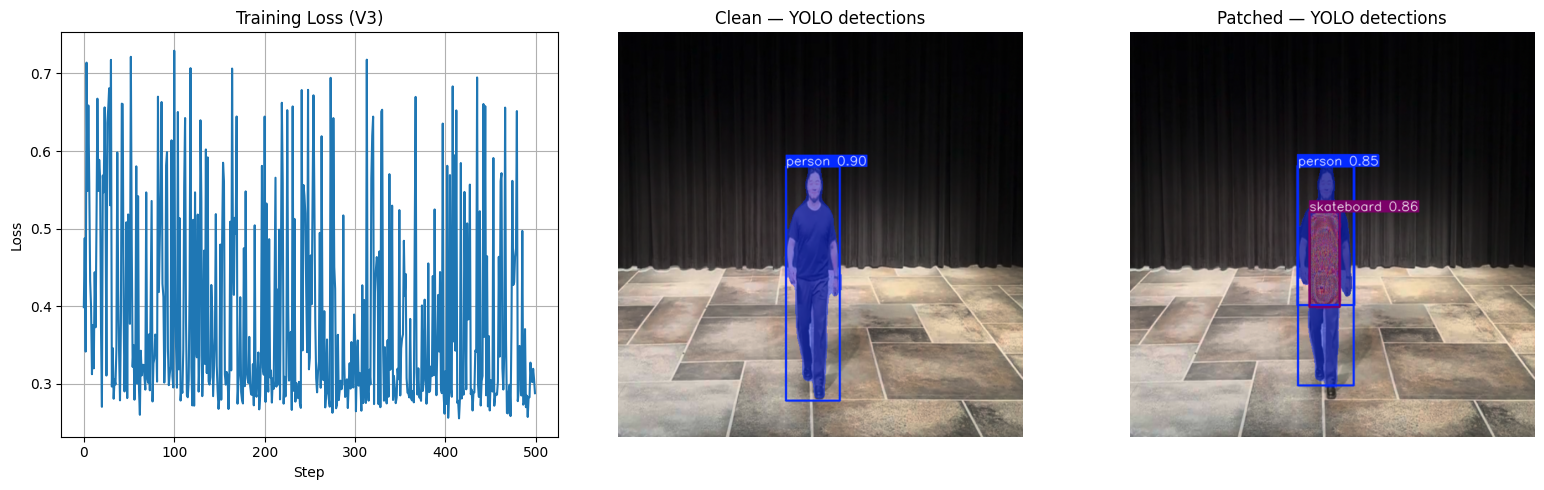

In [14]:
# Cell 13 — Visual evaluation
img_eval = cv2.imread(IMAGE_PATH)
img_640  = cv2.resize(img_eval, (640, 640))
box_eval_img, _ = detect_shirt_region(img_eval)

patch_np = patch.detach().cpu().squeeze().permute(1, 2, 0).numpy()
patch_np = (patch_np * 255).astype(np.uint8)

x1, y1, x2, y2 = box_eval_img
img_patched = img_640.copy()
img_patched[y1:y2, x1:x2] = cv2.cvtColor(
    cv2.resize(patch_np, (x2 - x1, y2 - y1)), cv2.COLOR_RGB2BGR
)

results_clean   = yolo(img_640,     verbose=False)
results_patched = yolo(img_patched, verbose=False)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].plot(loss_history)
axes[0].set_title('Training Loss (V3)')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Loss')
axes[0].grid(True)

axes[1].imshow(cv2.cvtColor(results_clean[0].plot(), cv2.COLOR_BGR2RGB))
axes[1].set_title('Clean — YOLO detections')
axes[1].axis('off')

axes[2].imshow(cv2.cvtColor(results_patched[0].plot(), cv2.COLOR_BGR2RGB))
axes[2].set_title('Patched — YOLO detections')
axes[2].axis('off')

plt.tight_layout()
plt.show()